# Title Page

**Adversarial AI in Games: Monte Carlo Simulation for 2-Player Briscas**

**Prepared for:** ICOM 5015 — Artificial Intelligence  

**Institution:** University of Puerto Rico at Mayagüez  

**Department:** Electrical and Computer Engineering  

**Prepared by:**Victor A. Gerena Hilerio,Jesus Y. Cabán Feliciano,Alejandro A. Roberts Quintana,Nollan N. Rivera Febus 

**Date:** May 8, 2026

This notebook presents the implementation and evaluation of a Briscas-playing agent. I kept the code and the report in the same notebook so the experiments can be rerun without having to switch between several files.


# Abstract

A two-player version of Briscas was implemented and tested as an adversarial AI problem. The main agent uses Monte Carlo simulation: for each legal move, it samples possible hidden card distributions, plays out the rest of the game several times, and chooses the move with the best average result. The implementation uses the AIMA Python `Game` interface for the general game structure, while the specific Briscas rules and agents were written in Python. The Monte Carlo player was compared with a random agent and a rule-based heuristic agent. Performance was measured using win rate, average score, and average score difference over repeated games. The results show how simulation-based decision making performs in a game with random dealing and hidden information.


# Table of Contents

1. [Introduction](#1.-Introduction)  
2. [Theoretical Background](#2.-Theoretical-Background)  
3. [Design and Implementation](#3.-Design-and-Implementation)  
   3.1 [Computational Environment and AIMA Python](#3.1-Computational-Environment-and-AIMA-Python)  
   3.2 [Card Representation and Spanish Deck](#3.2-Card-Representation-and-Spanish-Deck)  
   3.3 [Game State and AIMA Game Class](#3.3-Game-State-and-AIMA-Game-Class)  
   3.4 [Agent Designs](#3.4-Agent-Designs)  
   3.5 [Monte Carlo Hidden-State Sampling](#3.5-Monte-Carlo-Hidden-State-Sampling)  
   3.6 [Game Runner and Tournament Evaluation](#3.6-Game-Runner-and-Tournament-Evaluation)  
4. [Results and Analysis](#4.-Results-and-Analysis)  
5. [Conclusion](#5.-Conclusion)  
6. [Future Work](#6.-Future-Work)  
7. [References](#7.-References)  


# List of Tables and Figures

**Tables**  
**Table 1.** Tournament results for the main agent comparisons.  
**Table 2.** Effect of changing the number of Monte Carlo samples.

**Figures**  
**Figure 1.** Win rate comparison for the main experiments.  
**Figure 2.** Average score comparison for the main experiments.  
**Figure 3.** Effect of Monte Carlo sample count against the heuristic opponent.


# 1. Introduction

## Background

Briscas is a good fit for this assignment because it is not just a simple deterministic game. The cards are shuffled, each player only sees part of the state, and every move can affect later tricks. Because of that, the agent has to make decisions with incomplete information instead of simply searching a fully visible board.

## Purpose

The goal of this work is to build a Briscas agent that can play legal moves and then test whether its decisions are actually useful. For that reason, the project does not stop at implementing the rules. It also compares different agents over many games and reports the results using numerical metrics.

## Scope

The notebook uses a two-player version of Briscas. I did not include the Domino-specific team requirements because Briscas was selected instead of Domino. The evaluation focuses on the general requirements of the assignment: random and heuristic baselines, repeated games, win rate, score differences, robustness under different settings, and an optional human-play demonstration.


# 2. Theoretical Background

Briscas can be viewed as an adversarial game because one player's gain usually comes at the cost of the other player's result. It also has uncertainty. The initial shuffle is random, and after the deal each player knows only their own cards, the trump suit, the current trick, and the cards that have already been played.

A full minimax search is not a practical choice here. Even with only two players, the number of possible hands, draw orders, and future plays grows quickly. Instead, this notebook uses Monte Carlo simulation. The idea is to estimate the value of a move by trying many possible continuations of the game and averaging the outcomes. This gives the agent a way to reason about the future without building the complete game tree.

The AIMA Python `Game` class is used as the base interface. This is useful because it organizes the implementation around the same ideas used in adversarial search: legal actions, resulting states, terminal states, utility, and the player whose turn it is. The Briscas rules themselves still have to be implemented directly because AIMA does not include a ready-made Briscas environment.


# 3. Design and Implementation

This section contains the main code for the project. The implementation starts with the environment setup, then defines the deck, the game state, the Briscas transition rules, the agents, the hidden-card sampling method, and the tournament functions used for evaluation.


## 3.1 Computational Environment and AIMA Python

The next cell imports the required Python packages and loads the course-provided AIMA Python library. The Briscas environment is written as a subclass of AIMA's `Game` class, so the project uses an existing AI game framework while still implementing the actual Briscas rules.


In [1]:
import sys, os, random, zipfile, time
from pathlib import Path
from dataclasses import dataclass
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# AIMA-Python setup
# ---------------------------------------------------------------------------
# The notebook expects either:
#   1) an extracted folder named aima-python in the current directory, or
#   2) a file named aima-python.zip in the current directory or /mnt/data.

AIMA_DIR = Path('aima-python')
if not AIMA_DIR.exists():
    for zpath in [Path('aima-python.zip'), Path('/mnt/data/aima-python.zip')]:
        if zpath.exists():
            with zipfile.ZipFile(zpath, 'r') as zf:
                zf.extractall('.')
            break

sys.path.insert(0, str(AIMA_DIR.resolve()))

from games4e import Game

print('AIMA-Python loaded successfully.')


AIMA-Python loaded successfully.


## 3.2 Card Representation and Spanish Deck

Each card is stored as a tuple `(suit, rank)`. The deck has four Spanish suits and ten ranks per suit, for a total of 40 cards. The point system follows Briscas: the ace is worth 11 points, the three is worth 10, the king is worth 4, the horse is worth 3, and the sota is worth 2. All other cards are worth 0 points.


In [2]:
# ---------------------------------------------------------------------------
# Spanish deck: 40 cards = 4 suits x 10 ranks
# ---------------------------------------------------------------------------

SUITS = ('oros', 'copas', 'espadas', 'bastos')
RANKS = (1, 2, 3, 4, 5, 6, 7, 10, 11, 12)  # 10=Sota, 11=Caballo, 12=Rey

POINTS = {
    1: 11, 3: 10, 12: 4, 11: 3, 10: 2,
    2: 0, 4: 0, 5: 0, 6: 0, 7: 0,
}

# From weakest to strongest within a suit in Briscas.
RANK_ORDER = [2, 4, 5, 6, 7, 10, 11, 12, 3, 1]


def full_deck():
    return [(suit, rank) for suit in SUITS for rank in RANKS]


def card_points(card):
    return POINTS[card[1]]


def card_strength(card):
    return RANK_ORDER.index(card[1])


def card_str(card):
    names = {
        1: 'As', 2: '2', 3: '3', 4: '4', 5: '5',
        6: '6', 7: '7', 10: 'Sota', 11: 'Caballo', 12: 'Rey'
    }
    return f"{names[card[1]]}-{card[0]}"


deck = full_deck()
assert len(deck) == 40
assert sum(card_points(card) for card in deck) == 120

print(f'Deck size: {len(deck)} cards')
print(f'Total points in deck: {sum(card_points(card) for card in deck)}')
print('Example cards:', ', '.join(card_str(c) for c in deck[:8]))


Deck size: 40 cards
Total points in deck: 120
Example cards: As-oros, 2-oros, 3-oros, 4-oros, 5-oros, 6-oros, 7-oros, Sota-oros


## 3.3 Game State and AIMA Game Class

The state keeps all information needed to continue a game: both hands, the draw pile, the current trick, the trick leader, the next player, the trump suit, the score, and the cards that have already been played.

The `BriscasGame` class provides the methods expected by AIMA: `actions`, `result`, `utility`, `terminal_test`, and `to_move`. Together, these methods define the legal moves, the transition from one state to the next, when the game ends, and how a final position is scored.


In [3]:
class BriscasState:
    """
    Complete state of a 2-player Briscas round.

    The simulator stores the full state so that games can be executed exactly.
    The Monte Carlo agent only uses its own hand and the visible public state,
    then samples possible hidden worlds for the opponent hand and draw pile.
    """

    __slots__ = (
        'hands', 'deck', 'trick', 'trick_leader', 'to_move',
        'trump_suit', 'scores', 'played_cards'
    )

    def __init__(self, hands, deck, trick, trick_leader, to_move,
                 trump_suit, scores, played_cards=frozenset()):
        self.hands = hands                  # tuple(frozenset, frozenset)
        self.deck = deck                    # tuple of remaining cards
        self.trick = trick                  # tuple of (player, card)
        self.trick_leader = trick_leader    # player who led current trick
        self.to_move = to_move              # current player
        self.trump_suit = trump_suit
        self.scores = scores                # tuple(score_p0, score_p1)
        self.played_cards = frozenset(played_cards)

    @property
    def moves(self):
        # AIMA compatibility placeholder.
        return None

    def __repr__(self):
        return (
            f"BriscasState(to_move={self.to_move}, trump={self.trump_suit}, "
            f"hand_sizes={[len(h) for h in self.hands]}, deck={len(self.deck)}, "
            f"scores={self.scores})"
        )


def other(player):
    return 1 - player


def trick_winner(trick, trump_suit):
    """
    Return the winning player for a completed 2-card trick.
    """
    led_suit = trick[0][1][0]
    best_player, best_card = trick[0]
    best_is_trump = (best_card[0] == trump_suit)

    for player, card in trick[1:]:
        is_trump = (card[0] == trump_suit)
        follows_led = (card[0] == led_suit)

        if best_is_trump:
            if is_trump and card_strength(card) > card_strength(best_card):
                best_player, best_card, best_is_trump = player, card, True
        else:
            if is_trump:
                best_player, best_card, best_is_trump = player, card, True
            elif follows_led and card_strength(card) > card_strength(best_card):
                best_player, best_card = player, card

    return best_player


class BriscasGame(Game):
    """
    2-player Briscas implemented using the AIMA Game interface.
    """

    def __init__(self, seed=None):
        rng = random.Random(seed)
        deck = full_deck()
        rng.shuffle(deck)

        hands = (
            frozenset(deck[:3]),
            frozenset(deck[3:6]),
        )

        remaining_deck = tuple(deck[6:])
        trump_suit = remaining_deck[-1][0]

        self.initial = BriscasState(
            hands=hands,
            deck=remaining_deck,
            trick=tuple(),
            trick_leader=0,
            to_move=0,
            trump_suit=trump_suit,
            scores=(0, 0),
            played_cards=frozenset(),
        )

    def actions(self, state):
        return tuple(state.hands[state.to_move])

    def result(self, state, action):
        player = state.to_move
        if action not in state.hands[player]:
            raise ValueError(f'Illegal move: P{player} cannot play {action}')

        new_hands = [set(h) for h in state.hands]
        new_hands[player].remove(action)
        new_trick = tuple(list(state.trick) + [(player, action)])
        played_cards = set(state.played_cards)
        played_cards.add(action)

        # Trick is not complete yet.
        if len(new_trick) < 2:
            return BriscasState(
                hands=tuple(frozenset(h) for h in new_hands),
                deck=state.deck,
                trick=new_trick,
                trick_leader=state.trick_leader,
                to_move=other(player),
                trump_suit=state.trump_suit,
                scores=state.scores,
                played_cards=frozenset(played_cards),
            )

        # Complete trick: assigns points and draws cards.
        winner = trick_winner(new_trick, state.trump_suit)
        trick_points = sum(card_points(card) for _, card in new_trick)
        new_scores = list(state.scores)
        new_scores[winner] += trick_points

        new_deck = list(state.deck)
        if new_deck:
            # Winner draws first, then loser, as in Briscas.
            draw_order = [winner, other(winner)]
            for p in draw_order:
                if new_deck:
                    new_hands[p].add(new_deck.pop(0))

        return BriscasState(
            hands=tuple(frozenset(h) for h in new_hands),
            deck=tuple(new_deck),
            trick=tuple(),
            trick_leader=winner,
            to_move=winner,
            trump_suit=state.trump_suit,
            scores=tuple(new_scores),
            played_cards=frozenset(played_cards),
        )

    def utility(self, state, player):
        return state.scores[player] - state.scores[other(player)]

    def terminal_test(self, state):
        return (
            len(state.deck) == 0 and
            len(state.hands[0]) == 0 and
            len(state.hands[1]) == 0 and
            len(state.trick) == 0
        )

    def to_move(self, state):
        return state.to_move

    def display(self, state):
        print(state)
        print(f'Trump suit: {state.trump_suit}')
        print(f'Scores: P0={state.scores[0]} | P1={state.scores[1]}')
        print('Current trick:', [(p, card_str(c)) for p, c in state.trick])
        print('Hand P0:', [card_str(c) for c in state.hands[0]])
        print('Hand P1:', [card_str(c) for c in state.hands[1]])


## 3.4 Agent Designs

Three agents are used so the Monte Carlo player can be compared against simple baselines.

The **random agent** chooses any legal card with equal probability. This gives a naive baseline. The **heuristic agent** uses a few hand-coded Briscas ideas, such as not wasting trump cards too early and trying to win valuable tricks cheaply. The **Monte Carlo agent** evaluates each legal move by sampling possible hidden states and simulating the rest of the game.


In [4]:
def random_agent(game, state):
    """Baseline agent: chooses uniformly among legal cards."""
    return random.choice(game.actions(state))


def heuristic_score(card, state):
    """
    Simple Briscas heuristic.

    If leading, avoids spending trump unless necessary and prefers useful point cards.
    If following, tries to win cheaply; otherwise discards low-value cards.
    """
    is_trump = card[0] == state.trump_suit
    pts = card_points(card)

    if not state.trick:
        # Leads with point cards, but avoids wasting trump early.
        return pts * 10 + card_strength(card) - (25 if is_trump else 0)

    candidate_trick = tuple(list(state.trick) + [(state.to_move, card)])
    would_win = trick_winner(candidate_trick, state.trump_suit) == state.to_move
    pot = sum(card_points(c) for _, c in state.trick)

    if would_win:
        # Prefers winning valuable tricks while spending the cheapest winning card.
        return 500 + pot - pts - (5 if is_trump else 0)

    # If losing, avoids throwing points or trump.
    return -pts - (50 if is_trump else 0)


def heuristic_agent(game, state):
    moves = game.actions(state)
    return max(moves, key=lambda card: heuristic_score(card, state))


## 3.5 Monte Carlo Hidden-State Sampling

The Monte Carlo agent does not know the opponent's hand or the order of the remaining draw pile. To handle that, it builds possible hidden worlds that agree with what the player has actually seen. The known information includes the player's own hand, cards already played, cards in the current trick, and the trump suit.

For each candidate move, the agent samples several possible worlds, plays the move in those worlds, rolls the game forward, and averages the resulting utility. The move with the highest average utility is selected.


In [5]:
def sample_hidden_world(state, observer):
    """
    Sample a fully observable state consistent with the observer's information.

    Observer knows:
      - own hand,
      - cards already played,
      - current trick cards,
      - trump suit.

    The opponent hand and draw pile are sampled from the remaining unseen cards.
    """
    known = set(state.hands[observer]) | set(state.played_cards) | {c for _, c in state.trick}
    hidden_pool = [card for card in full_deck() if card not in known]
    random.shuffle(hidden_pool)

    opponent = other(observer)
    opp_size = len(state.hands[opponent])
    deck_size = len(state.deck)

    new_hands = [set(), set()]
    new_hands[observer] = set(state.hands[observer])
    new_hands[opponent] = set(hidden_pool[:opp_size])
    new_deck = tuple(hidden_pool[opp_size:opp_size + deck_size])

    return BriscasState(
        hands=tuple(frozenset(h) for h in new_hands),
        deck=new_deck,
        trick=state.trick,
        trick_leader=state.trick_leader,
        to_move=state.to_move,
        trump_suit=state.trump_suit,
        scores=state.scores,
        played_cards=state.played_cards,
    )


def rollout(game, state, perspective_player, rollout_policy=heuristic_agent):
    """Simulate to the end and return utility for the original AI player."""
    while not game.terminal_test(state):
        move = rollout_policy(game, state)
        state = game.result(state, move)
    return game.utility(state, perspective_player)


def make_monte_carlo_agent(num_samples=30, rollout_policy=heuristic_agent):
    """
    Monte Carlo Averaging-over-Clairvoyance agent.

    For every legal move, the agent samples possible hidden worlds and estimates
    the move's value by average rollout utility.
    """
    def mc_agent(game, state):
        legal_moves = game.actions(state)
        if len(legal_moves) == 1:
            return legal_moves[0]

        observer = state.to_move
        move_values = defaultdict(float)

        for move in legal_moves:
            total = 0.0
            for _ in range(num_samples):
                sampled_state = sample_hidden_world(state, observer)

                # If the sampled world accidentally makes the move illegal, skips it.
                if move not in sampled_state.hands[observer]:
                    continue

                next_state = game.result(sampled_state, move)
                total += rollout(game, next_state, observer, rollout_policy)

            move_values[move] = total / max(1, num_samples)

        return max(legal_moves, key=lambda m: move_values[m])

    mc_agent.__name__ = f'monte_carlo_agent_{num_samples}'
    return mc_agent


mc_fast = make_monte_carlo_agent(num_samples=10)
mc_medium = make_monte_carlo_agent(num_samples=30)
mc_strong = make_monte_carlo_agent(num_samples=80)


## 3.6 Game Runner and Tournament Evaluation

The following functions run complete games and repeated matches. Repetition is important because one or two games can be misleading in a card game. A player can win a single game because of a favorable shuffle, so the comparison has to be based on many games.


In [6]:
def play_game(agent0, agent1, seed=None, verbose=False):
    """Play one full 2-player Briscas round.

    The optional seed controls both the card deal and the random choices
    made by stochastic agents/Monte Carlo sampling. This makes experiments
    reproducible when the notebook is rerun.
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    game = BriscasGame(seed=seed)
    state = game.initial
    agents = [agent0, agent1]

    if verbose:
        print(f'Trump suit: {state.trump_suit}\n')

    while not game.terminal_test(state):
        player = state.to_move
        move = agents[player](game, state)
        if verbose:
            print(f'P{player} plays {card_str(move)}')
        state = game.result(state, move)
        if verbose and len(state.trick) == 0:
            print(f'  Scores: P0={state.scores[0]} | P1={state.scores[1]}')
            print(f'  Next leader: P{state.to_move}\n')

    if state.scores[0] > state.scores[1]:
        winner = 0
    elif state.scores[1] > state.scores[0]:
        winner = 1
    else:
        winner = 'tie'

    return {
        'score_p0': state.scores[0],
        'score_p1': state.scores[1],
        'score_diff_p0': state.scores[0] - state.scores[1],
        'winner': winner,
    }


def run_match(agent0, agent1, n_games=100, seed_start=0, label=''):
    """Run many games and summarize win rate and score difference."""
    results = []
    for i in range(n_games):
        results.append(play_game(agent0, agent1, seed=seed_start + i))

    wins0 = sum(1 for r in results if r['winner'] == 0)
    wins1 = sum(1 for r in results if r['winner'] == 1)
    ties = sum(1 for r in results if r['winner'] == 'tie')

    avg0 = np.mean([r['score_p0'] for r in results])
    avg1 = np.mean([r['score_p1'] for r in results])
    avgdiff = np.mean([r['score_diff_p0'] for r in results])

    return {
        'label': label,
        'games': n_games,
        'wins_p0': wins0,
        'wins_p1': wins1,
        'ties': ties,
        'win_rate_p0': wins0 / n_games,
        'win_rate_p1': wins1 / n_games,
        'avg_score_p0': avg0,
        'avg_score_p1': avg1,
        'avg_score_diff_p0': avgdiff,
    }


# 4. Results and Analysis

The main evaluation compares the Monte Carlo agent with a random opponent and with a stronger heuristic opponent. A third comparison, heuristic versus random, is included to show whether the heuristic baseline is actually stronger than random play.

Table 1 reports the number of games, wins, win rate, average score, and average score difference. These values are the main evidence used to judge whether the agent is performing better than the baselines.

**Table 1. Tournament results for the main agent comparisons.**


In [ ]:
random.seed(0)
np.random.seed(0)

rand = random_agent
heur = heuristic_agent
mc = mc_fast  

N_GAMES = 100

experiments = {}
experiments['mc_vs_random'] = run_match(
    mc, rand, n_games=N_GAMES, seed_start=0,
    label='Monte Carlo vs Random'
)
experiments['mc_vs_heuristic'] = run_match(
    mc, heur, n_games=N_GAMES, seed_start=1000,
    label='Monte Carlo vs Heuristic'
)
experiments['heuristic_vs_random'] = run_match(
    heur, rand, n_games=N_GAMES, seed_start=2000,
    label='Heuristic vs Random'
)

results_df = pd.DataFrame([
    {
        'Experiment': r['label'],
        'Games': r['games'],
        'P0 Wins': r['wins_p0'],
        'P1 Wins': r['wins_p1'],
        'Ties': r['ties'],
        'P0 Win Rate (%)': round(100 * r['win_rate_p0'], 1),
        'Avg P0 Score': round(r['avg_score_p0'], 2),
        'Avg P1 Score': round(r['avg_score_p1'], 2),
        'Avg Score Diff (P0-P1)': round(r['avg_score_diff_p0'], 2),
    }
    for r in experiments.values()
])

results_df


,Experiment,Games,P0 Wins,P1 Wins,Ties,P0 Win Rate (%),Avg P0 Score,Avg P1 Score,Avg Score Diff (P0-P1)
0,Monte Carlo vs Random,100,83,17,0,83.0,77.68,42.32,35.36
1,Monte Carlo vs Heuristic,100,62,34,4,62.0,67.04,52.96,14.08
2,Heuristic vs Random,100,82,16,2,82.0,78.85,41.15,37.70


Figures 1 and 2 show the same main experiment results from Table 1 in graphical form. Figure 1 emphasizes win rate, while Figure 2 shows the average number of points scored by each player. The graphs make it easier to see the performance gap between the agents.


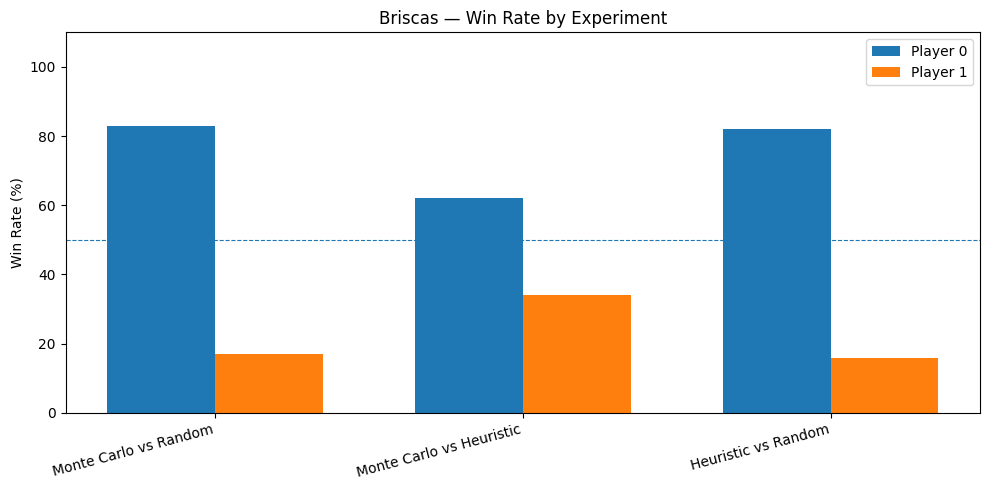

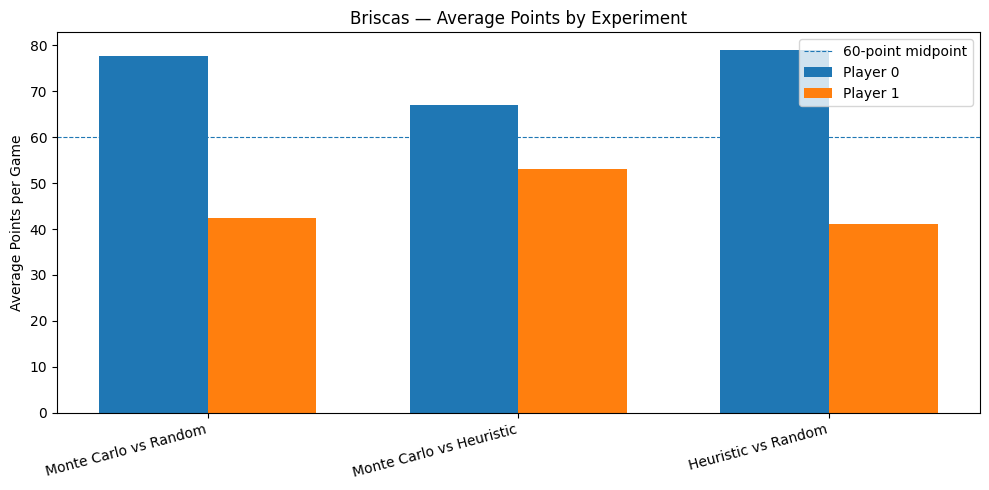

In [8]:
labels = [r['label'] for r in experiments.values()]
wr0 = [100 * r['win_rate_p0'] for r in experiments.values()]
wr1 = [100 * r['win_rate_p1'] for r in experiments.values()]
avg0 = [r['avg_score_p0'] for r in experiments.values()]
avg1 = [r['avg_score_p1'] for r in experiments.values()]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, wr0, width, label='Player 0')
plt.bar(x + width/2, wr1, width, label='Player 1')
plt.axhline(50, linestyle='--', linewidth=0.8)
plt.xticks(x, labels, rotation=15, ha='right')
plt.ylabel('Win Rate (%)')
plt.title('Briscas — Win Rate by Experiment')
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.savefig('briscas_2player_win_rates.png', dpi=120)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, avg0, width, label='Player 0')
plt.bar(x + width/2, avg1, width, label='Player 1')
plt.axhline(60, linestyle='--', linewidth=0.8, label='60-point midpoint')
plt.xticks(x, labels, rotation=15, ha='right')
plt.ylabel('Average Points per Game')
plt.title('Briscas — Average Points by Experiment')
plt.legend()
plt.tight_layout()
plt.savefig('briscas_2player_average_points.png', dpi=120)
plt.show()


**Figure 1. Win rate comparison for the main experiments.**  
**Figure 2. Average score comparison for the main experiments.**

The Monte Carlo player should have an advantage over the random player because it does not choose blindly. It estimates possible outcomes before selecting a card. The comparison against the heuristic player is more demanding because that opponent already uses game-specific rules. If the Monte Carlo agent only wins by a smaller margin there, that still makes sense: it is being tested against a stronger baseline.


## 4.1 Monte Carlo Sample-Count Ablation

This experiment changes the number of simulations used by the Monte Carlo agent. More samples should usually give a better estimate of each move, but they also make each decision slower.

The results do not have to improve perfectly from left to right. The experiment still depends on sampled games, so small ups and downs can happen. What matters is whether the sample count gives a reasonable picture of the tradeoff between decision quality and runtime.

**Table 2. Effect of changing the number of Monte Carlo samples.**


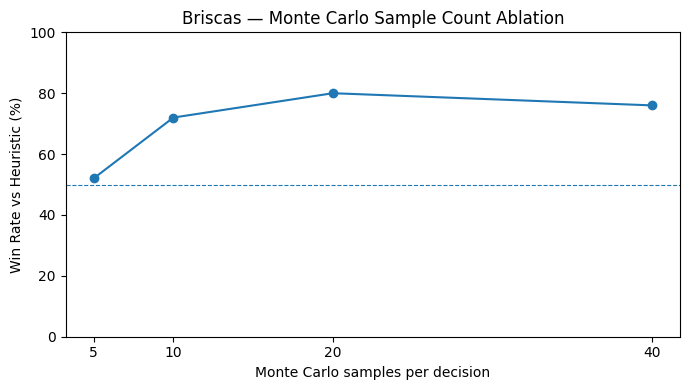

,Monte Carlo Samples per Decision,Win Rate vs Heuristic (%),Avg Score Diff (P0-P1)
0,5,52.0,0.80
1,10,72.0,10.32
2,20,80.0,26.72
3,40,76.0,24.72


In [9]:
random.seed(1)
np.random.seed(1)

sample_counts = [5, 10, 20, 40]
ablation = []

for samples in sample_counts:
    agent = make_monte_carlo_agent(num_samples=samples)
    result = run_match(
        agent, heuristic_agent,
        n_games=25,
        seed_start=5000 + samples,
        label=f'MC({samples}) vs Heuristic'
    )
    ablation.append((samples, result['win_rate_p0'], result['avg_score_diff_p0']))

samples, rates, diffs = zip(*ablation)

plt.figure(figsize=(7, 4))
plt.plot(samples, [100 * r for r in rates], marker='o')
plt.axhline(50, linestyle='--', linewidth=0.8)
plt.xlabel('Monte Carlo samples per decision')
plt.ylabel('Win Rate vs Heuristic (%)')
plt.title('Briscas — Monte Carlo Sample Count Ablation')
plt.xticks(samples)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('briscas_2player_ablation.png', dpi=120)
plt.show()

ablation_df = pd.DataFrame({
    'Monte Carlo Samples per Decision': samples,
    'Win Rate vs Heuristic (%)': [round(100 * r, 1) for r in rates],
    'Avg Score Diff (P0-P1)': [round(d, 2) for d in diffs],
})

ablation_df


**Figure 3. Effect of Monte Carlo sample count against the heuristic opponent.**

Figure 3 shows the practical cost of using Monte Carlo reasoning. With very few samples, the agent makes faster decisions but the estimates can be noisy. With more samples, the estimates are more stable, but the program takes longer to play. This is an important limitation because a game-playing AI has to balance move quality with response time.


# 5. Conclusion

A two-player Briscas environment was implemented and evaluated using the AIMA Python `Game` interface. The rules of the game, the state transitions, and the agents were implemented directly in Python. The main AI player used Monte Carlo simulation to estimate the value of legal moves under hidden information.

The experiments show why repeated evaluation is necessary. The Monte Carlo agent performs much better than random play, which suggests that simulating possible futures is useful for this game. The heuristic comparison is more difficult because the heuristic agent already uses Briscas-specific knowledge. This comparison is useful because it shows that a stronger baseline gives a more realistic test than random play alone.

The sample-count experiment also shows a limitation of the approach. Monte Carlo decisions depend on the number of simulations. More samples can improve the estimate, but they also increase the time needed for each move.


# 6. Future Work

There are several ways to improve this project. The rollout policy could be made stronger so that simulated games are closer to realistic play. The Monte Carlo agent could also use more samples or parallel simulations to reduce noise without making the notebook too slow.

Another useful extension would be to run a larger tournament with human players. That would show whether the agent's strategy works against opponents who do not behave like the coded baselines. The project could also be expanded to a four-player version of Briscas or to a learning agent that improves through self-play.


# 7. References

[1] N. G. Santiago and M. A. Jiménez, *Writing Formal Reports: An Approach for Engineering Students in 21st Century*, 3rd ed., Department of Electrical and Computer Engineering, University of Puerto Rico at Mayagüez, 2002.

[2] S. Russell and P. Norvig, *Artificial Intelligence: A Modern Approach*, 4th ed. Pearson, 2021.

[3] AIMA Python Project, “aima-python,” GitHub repository, accessed through the course-provided `aima-python.zip` file.

[4] ICOM 5015 Artificial Intelligence course materials, Chapter 5: Adversarial Search.


# Appendix A: Demonstration and Oral Explanation

This appendix includes a small demo game and a short script for the oral explanation. The demo is not used to compute the main results, but it is useful for showing that the agent actually plays full games.


## A.1 Demo Game

The next cell runs one game with printed moves so the play sequence can be checked manually.


In [10]:
print('Demo game: Monte Carlo AI as Player 0 vs Heuristic as Player 1\n')
demo = play_game(mc, heuristic_agent, seed=7, verbose=True)
print('Final result:', demo)


Demo game: Monte Carlo AI as Player 0 vs Heuristic as Player 1

Trump suit: espadas

P0 plays 6-bastos
P1 plays 6-copas
  Scores: P0=0 | P1=0
  Next leader: P0

P0 plays As-bastos
P1 plays 2-espadas
  Scores: P0=0 | P1=11
  Next leader: P1

P1 plays As-copas
P0 plays 2-copas
  Scores: P0=0 | P1=22
  Next leader: P1

P1 plays Rey-bastos
P0 plays 6-oros
  Scores: P0=0 | P1=26
  Next leader: P1

P1 plays Rey-copas
P0 plays 3-copas
  Scores: P0=14 | P1=26
  Next leader: P0

P0 plays Caballo-bastos
P1 plays Caballo-espadas
  Scores: P0=14 | P1=32
  Next leader: P1

P1 plays 3-espadas
P0 plays 5-copas
  Scores: P0=14 | P1=42
  Next leader: P1

P1 plays Caballo-copas
P0 plays 2-bastos
  Scores: P0=14 | P1=45
  Next leader: P1

P1 plays Caballo-oros
P0 plays As-oros
  Scores: P0=28 | P1=45
  Next leader: P0

P0 plays 5-espadas
P1 plays 7-espadas
  Scores: P0=28 | P1=45
  Next leader: P1

P1 plays Sota-copas
P0 plays 4-copas
  Scores: P0=28 | P1=47
  Next leader: P1

P1 plays 3-oros
P0 plays 2-

## A.2 Human vs AI Demonstration

The next cell is optional. It can be uncommented during the oral demonstration if someone wants to play against the Monte Carlo agent.


In [11]:
def human_agent(game, state):
    """Interactive human player for demonstration."""
    game.display(state)
    moves = game.actions(state)
    print('\nYour legal cards:')
    for i, card in enumerate(moves):
        print(f'[{i}] {card_str(card)}')
    while True:
        try:
            choice = int(input('Choose card index: '))
            if 0 <= choice < len(moves):
                return moves[choice]
        except Exception:
            pass
        print('Invalid choice. Try again.')


# Uncomment the following line to play as Player 0 against the Monte Carlo AI.
# play_game(human_agent, mc_medium, seed=42, verbose=True)
